# Biopandas for PDB files
-----------------------------------------------------------------------------
## Overview
If you are a structural biologist working with molecular structure files, a fantastic way to process pdb files is with Pandas dataframes. The tools are beyond the scope of this Introduction to Python course, but we include it here to give you a taste of how you can use traditional programming to query and calculate with these complex file types.

## Learning objectives
After this submodule, you will be able to:
1. Import at pdb file from the rcsb using biopandas
2. Access dataframes within the file
3. Calculate from and analyze series
4. Carry out an exercise identifying a ligand binding site in a structure

## Prerequisites
- Knowledge of pandas

## Getting Started
Run the next code box to install pandas, numpy, and biopandas

In [3]:
%pip install pandas
%pip install biopandas

import pandas as pd
import numpy as np
from biopandas.pdb import PandasPdb


Note: you may need to restart the kernel to use updated packages.


# Importing a pdb file into a pandas dataframe

As with Biopython, biopandas has functions that are well adapted for biological data types. The protein data bank format (PDB) is a large data file that contains the position and identity of every atom in the 3D structure. 

The file can be imported directly from the RCSB using fetch_pdb as shown. 

In [9]:
ppdb = PandasPdb().fetch_pdb('3eiy')
ppdb.df['ATOM'].tail()

,record_name,atom_number,blank_1,atom_name,alt_loc,residue_name,blank_2,chain_id,residue_number,insertion,...,x_coord,y_coord,z_coord,occupancy,b_factor,blank_4,segment_id,element_symbol,charge,line_idx
1325,ATOM,1326,,CG,,LYS,,A,175,,...,6.957,36.545,-11.369,1.0,57.59,,,C,NaN,1936
1326,ATOM,1327,,CD,,LYS,,A,175,,...,6.501,37.199,-12.700,1.0,61.87,,,C,NaN,1937
1327,ATOM,1328,,CE,,LYS,,A,175,,...,7.706,37.673,-13.531,1.0,63.51,,,C,NaN,1938
1328,ATOM,1329,,NZ,,LYS,,A,175,,...,8.861,36.709,-13.496,1.0,63.20,,,N,NaN,1939
1329,ATOM,1330,,OXT,,LYS,,A,175,,...,10.451,35.432,-10.086,1.0,55.71,,,O,NaN,1940


In [17]:
ppdb.df['ATOM']["residue_name"].unique()

array(['SER', 'PHE', 'ASN', 'VAL', 'PRO', 'ALA', 'GLY', 'LYS', 'ASP',
       'LEU', 'GLN', 'ILE', 'GLU', 'TYR', 'ARG', 'THR', 'MET', 'HIS',
       'CYS', 'TRP'], dtype=object)

In [19]:
ppdb.df['ATOM']["b_factor"].mean()

29.33957894736842

In [23]:
ppdb.df['HETATM'].head()

,record_name,atom_number,blank_1,atom_name,alt_loc,residue_name,blank_2,chain_id,residue_number,insertion,...,x_coord,y_coord,z_coord,occupancy,b_factor,blank_4,segment_id,element_symbol,charge,line_idx
0,HETATM,1332,,K,,K,,A,176,,...,24.990,43.276,0.005,0.5,24.45,,,K,NaN,1942
1,HETATM,1333,,NA,,NA,,A,177,,...,1.633,34.181,11.897,1.0,26.73,,,NA,NaN,1943
2,HETATM,1334,,NA,,NA,,A,178,,...,6.489,35.143,8.444,1.0,30.89,,,NA,NaN,1944
3,HETATM,1335,,P1,,POP,,A,179,,...,1.233,37.542,11.212,1.0,32.68,,,P,NaN,1945
4,HETATM,1336,,O1,,POP,,A,179,,...,1.910,38.831,11.612,1.0,32.62,,,O,NaN,1946


It is easy to identify all the heteroatoms in this structure file:

In [25]:
ppdb.df['HETATM']['residue_name'].unique()

array(['K', 'NA', 'POP', 'PG4', 'PEG', 'HOH'], dtype=object)

Because this is a pandas **series** rather than a type count works on (that is, strings, lists, tuples, sets and dictionaries), the tool to 'count' items is slightly different: df.value_counts()\[value]

Can you also identify how many sodium atoms are in the structure file?

In [46]:
ppdb.df['HETATM']['residue_name'].value_counts()['HOH']

112

## Exercise: Identifying the ligand binding residues 
In this project, you'll analyze a protein-ligand complex from a PDB file to:

1. Extract and explore atomic information.
2. Identify the binding site of the ligand.
3. Calculate distances between the ligand and nearby protein residues.
4. Visualize the results using Python.

You should re-run it with a different pdb file and ligand to see how it can work for you.

On a PC, many of these steps take ~10min to run. This is where cloud computing shows it's power & utility!

### Step one: Get the file
Assign the pdb file to the variable pdb  PDB ID: 4AKE (adenylate kinase with a bound ligand). 

As always, look at the first few lines of the file to make sure it is what you expected and to see the column names

In [11]:
# Load the PDB file
pdb = PandasPdb().fetch_pdb('4CFF')

# View the ATOM and HETATM data
print(pdb.df['ATOM'].head())  # Protein atoms
print(pdb.df['HETATM'].head())  # Ligand or non-standard residues
pdb.df['HETATM']['residue_name'].unique()

  record_name  atom_number blank_1 atom_name alt_loc residue_name blank_2  \
0        ATOM            1                 N                  ASP           
1        ATOM            2                CA                  ASP           
2        ATOM            3                 C                  ASP           
3        ATOM            4                 O                  ASP           
4        ATOM            5                CB                  ASP           

  chain_id  residue_number insertion  ... x_coord  y_coord  z_coord  \
0        A               8            ... -29.840  -11.903  223.950   
1        A               8            ... -28.439  -12.150  223.622   
2        A               8            ... -28.276  -12.622  222.180   
3        A               8            ... -29.233  -12.609  221.406   
4        A               8            ... -27.834  -13.178  224.583   

   occupancy  b_factor  blank_4 segment_id element_symbol charge  line_idx  
0        1.0    123.00           

array(['TPO', 'SEP', 'STU', 'C1V', 'AMP'], dtype=object)

### Step two: Filter the Ligand Data
Identify and extract the ligand information (from the HETATM section).

In [15]:
# Extract the ligand (e.g., "AMP" for adenylate)
amp_ligand = pdb.df['HETATM'][pdb.df['HETATM']['residue_name'] == 'AMP']
print(amp_ligand.iloc[1:5,1:8])


     atom_number blank_1 atom_name alt_loc residue_name blank_2 chain_id
165        14400               O1P                  AMP                E
166        14401               O2P                  AMP                E
167        14402               O3P                  AMP                E
168        14403               O5'                  AMP                E


### Step three: Identify Nearby Protein Atoms
Calculate the distance between the ligand and nearby protein atoms to identify potential binding site residues.

In [17]:
# Extract protein atoms
protein_atoms = pdb.df['ATOM']

# Define a function to calculate distances
def calculate_distance(coord1, coord2):
    return np.linalg.norm(coord1 - coord2)

# Find nearby protein atoms within 5Å of the ligand
binding_site = []
for _, ligand_row in amp_ligand.iterrows():
    ligand_coords = np.array([ligand_row['x_coord'], ligand_row['y_coord'], ligand_row['z_coord']])
    for _, protein_row in protein_atoms.iterrows():
        protein_coords = np.array([protein_row['x_coord'], protein_row['y_coord'], protein_row['z_coord']])
        distance = calculate_distance(ligand_coords, protein_coords)
        if distance <= 5.0:
            binding_site.append(protein_row)

# Convert the binding site data to a DataFrame
binding_site_df = pd.DataFrame(binding_site)
print(binding_site_df)

      record_name  atom_number blank_1 atom_name alt_loc residue_name blank_2  \
9809         ATOM         9856                CZ                  ARG           
9811         ATOM         9858               NH2                  ARG           
10631        ATOM        10678                CE                  LYS           
10632        ATOM        10679                NZ                  LYS           
11210        ATOM        11257                CB                  SER           
...           ...          ...     ...       ...     ...          ...     ...   
13441        ATOM        13489                CB                  VAL           
13442        ATOM        13490               CG1                  VAL           
14136        ATOM        14184                CB                  ILE           
14137        ATOM        14185               CG1                  ILE           
14138        ATOM        14186               CG2                  ILE           

      chain_id  residue_num

### Step 4: Visualize the Results
Plot the ligand and the binding site residues in 3D using Matplotlib.

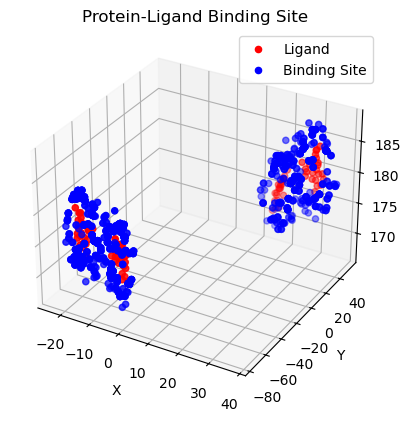

In [21]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Extract coordinates
ligand_coords = amp_ligand[['x_coord', 'y_coord', 'z_coord']].values
protein_coords = binding_site_df[['x_coord', 'y_coord', 'z_coord']].values

# Create a 3D scatter plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot ligand
ax.scatter(ligand_coords[:, 0], ligand_coords[:, 1], ligand_coords[:, 2], color='red', label='Ligand')

# Plot binding site residues
ax.scatter(protein_coords[:, 0], protein_coords[:, 1], protein_coords[:, 2], color='blue', label='Binding Site')

# Label the plot
ax.set_title("Protein-Ligand Binding Site")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()

plt.show()

You can see the 4 AMP molecules (in red) with the nearby atoms. 

### Step 5: Get a dataframe of the nearby amino acids
In the previous steps we identified all the nearby **atoms**. Here, we collect the names of the nearby residues. We are putting the residue information into a SET which  will only add (add()) unique elements. *This step can take some time.*

In [23]:
# Find amino acids near AMP ligand
nearby_residues = set()  # To store unique residues
distance_threshold = 3.0  # Distance threshold in Å. Consider adding a user input to ask you for the distance

for _, ligand_row in amp_ligand.iterrows():
    ligand_coords = np.array([ligand_row['x_coord'], ligand_row['y_coord'], ligand_row['z_coord']])
    for _, protein_row in protein_atoms.iterrows():
        protein_coords = np.array([protein_row['x_coord'], protein_row['y_coord'], protein_row['z_coord']])
        distance = calculate_distance(ligand_coords, protein_coords)
        if distance <= distance_threshold:
            # Add residue information to the set
            residue_info = f"{protein_row['residue_name']} {protein_row['residue_number']} {protein_row['chain_id']}"
            nearby_residues.add(residue_info)

# Display the nearby residues
print("Amino acids near AMP ligand:")
residue_set=set()
for residue in sorted(nearby_residues):
    residue_set.add(residue) #only adds unique elements

print("Residue # Chain")
for line in residue_set:
    print(line)

Amino acids near AMP ligand:
Residue # Chain
SER 226 E
SER 314 E
ASP 317 F
HIS 151 F
SER 242 E
ARG 299 F
ALA 227 E
THR 200 E
THR 200 F
VAL 276 F
LEU 277 E
SER 316 E
ALA 227 F
SER 242 F
LYS 170 E
HIS 298 E
LYS 170 F
ALA 205 F
ARG 269 E
SER 226 F
ASP 317 E
SER 316 F
HIS 151 E


# Conclusion
You should see the potential power of Pandas to process even complex structure data files.  Perhaps you can envision using a python script to collect and compare hundreds of AMP binding sites from protein files. Hopefully, you edited the scripts above to look at a protein of your choice or to use other tools from previous tutorials!

You should now learn about more about the tools available in python for [visualizing your data]("./Submodule_2_Tutorial3_VisualizingData.ipynb")

## Clean up
After you are done, be sure to stop the compute instance for this Jupyter notebook to avoid unnecessary charges.